# Off-grid patch sampling — a visual walk-through

This notebook shows, on a **single image**, how PART's pretext task starts: by
cutting an image into patches via **off-grid sampling**.

We use the pared-down RoPART helpers in [`helpers/`](helpers/), which port only
what the **translation-only baseline** needs from upstream
`PART/make_dataset.py`:

- **off-grid sampling** — patch top-left corners are continuous (any pixel
  offset), *not* snapped to a `patch_size` grid;
- **constant patch size** — every patch is `patch_size × patch_size`. Upstream
  `v3` uses *variable*-size boxes; fixing the size removes the scale/aspect
  signal `(Δw, Δh)`, which is exactly the baseline geometry (no scale channel).

This is the sampling half of the pretext pipeline; the target half follows in
the sections below.

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt

from helpers import (
    load_image,
    sample_offgrid_patches,
    crop_patches,
    retile_patches,
    draw_boxes,
    show_patch_grid,
    show_sampling_overview,
)

## 1. Load the image

A 512×512 photo. We keep it at native resolution so the patches are big enough
to actually look at.

image: (512, 512, 3) uint8


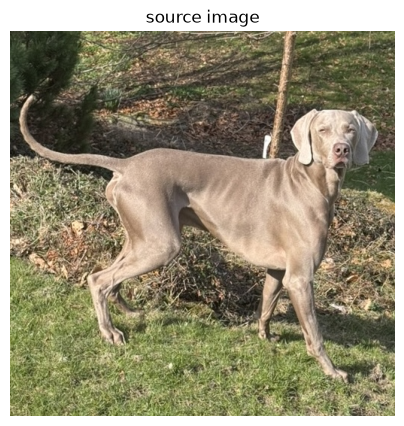

In [2]:
IMG_SIZE = 512      # source image side
PATCH_SIZE = 64     # constant patch side
NUM_PATCHES = 64    # must be a perfect square for the row-major packing below

image = load_image("example.jpeg", img_size=IMG_SIZE)
print("image:", image.shape, image.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title("source image")
plt.show()

## 2. Sample off-grid patch boxes

`sample_offgrid_patches` draws `NUM_PATCHES` top-left corners uniformly from the
valid range `[0, IMG_SIZE - PATCH_SIZE]` (independently per axis) and returns
boxes as a `(4, N)` tensor with rows `(x_start, y_start, x_end, y_end)` — the
same layout upstream uses for its targets.

Because positions are continuous, patches **overlap** and do not align to any
grid. A fixed `generator` seed makes the sample reproducible.

In [3]:
g = torch.Generator().manual_seed(0)
boxes = sample_offgrid_patches(IMG_SIZE, PATCH_SIZE, NUM_PATCHES, generator=g)

print("boxes:", tuple(boxes.shape), boxes.dtype)
print("rows = (x_s, y_s, x_e, y_e); first 5 boxes:")
print(boxes[:, :5])

# every box is PATCH_SIZE square (constant size):
widths = boxes[2] - boxes[0]
heights = boxes[3] - boxes[1]
print("unique widths:", widths.unique().tolist(), "| unique heights:", heights.unique().tolist())

boxes: (4, 64) torch.int64
rows = (x_s, y_s, x_e, y_e); first 5 boxes:
tensor([[ 90, 220, 418, 292, 273],
        [339, 140,  46, 378, 104],
        [154, 284, 482, 356, 337],
        [403, 204, 110, 442, 168]])
unique widths: [64] | unique heights: [64]


Overlay the sampled boxes on the source image. Each box is coloured and
numbered by its sampling index. Note the overlap and the off-grid placement.

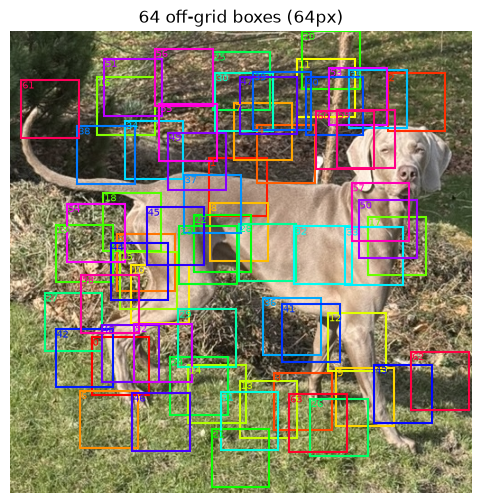

In [4]:
draw_boxes(image, boxes, title=f"{NUM_PATCHES} off-grid boxes ({PATCH_SIZE}px)")
plt.show()

With fewer, larger patches the off-grid nature is even clearer — let's draw
just 8 thicker boxes.

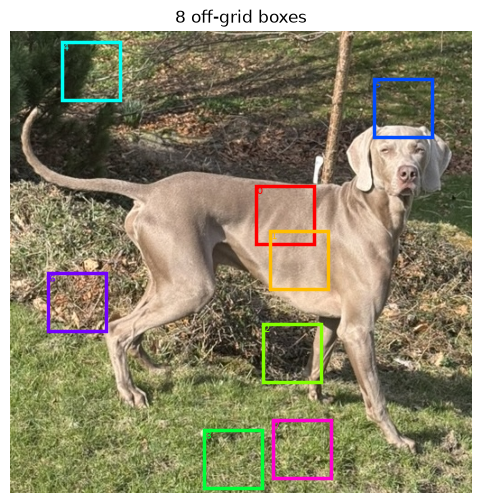

In [5]:
g8 = torch.Generator().manual_seed(1)
boxes8 = sample_offgrid_patches(IMG_SIZE, PATCH_SIZE, 8, generator=g8)
draw_boxes(image, boxes8, title="8 off-grid boxes", linewidth=2.5)
plt.show()

## 3. Crop the patches

`crop_patches` extracts each box and returns a
`(N, C, PATCH_SIZE, PATCH_SIZE)` `float32` tensor in `[0, 1]`. With constant
patch size there is **no resize** — upstream resizes only because its `v3` boxes
vary in size.

patches: (64, 3, 64, 64) torch.float32 range (0.0, 1.0)


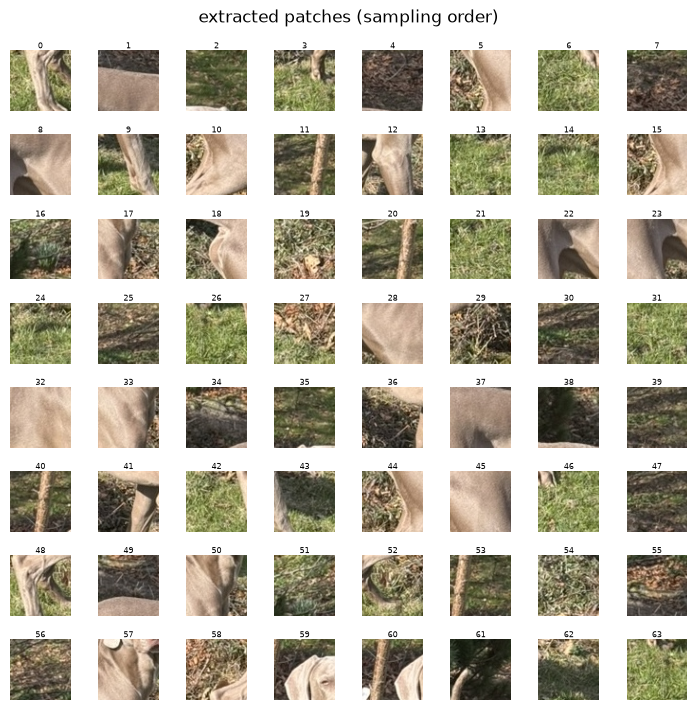

In [6]:
patches = crop_patches(image, boxes)
print("patches:", tuple(patches.shape), patches.dtype, "range", (patches.min().item(), patches.max().item()))

show_patch_grid(patches, title="extracted patches (sampling order)")
plt.show()

## 4. Pack patches into the ViT input

`retile_patches` lays the patches row-major into a single
`(C, IMG_SIZE, IMG_SIZE)` image — exactly the reshape/permute upstream does so a
standard ViT `patch_embed` conv turns them back into tokens.

This is a **packing, not a reconstruction**: patch order has nothing to do with
where each patch came from, so the result looks scrambled. That is the whole
point — the network is handed the patches with **no positional information**, and
the pretext task is to predict the relative geometry it was denied.

retiled: (3, 512, 512)


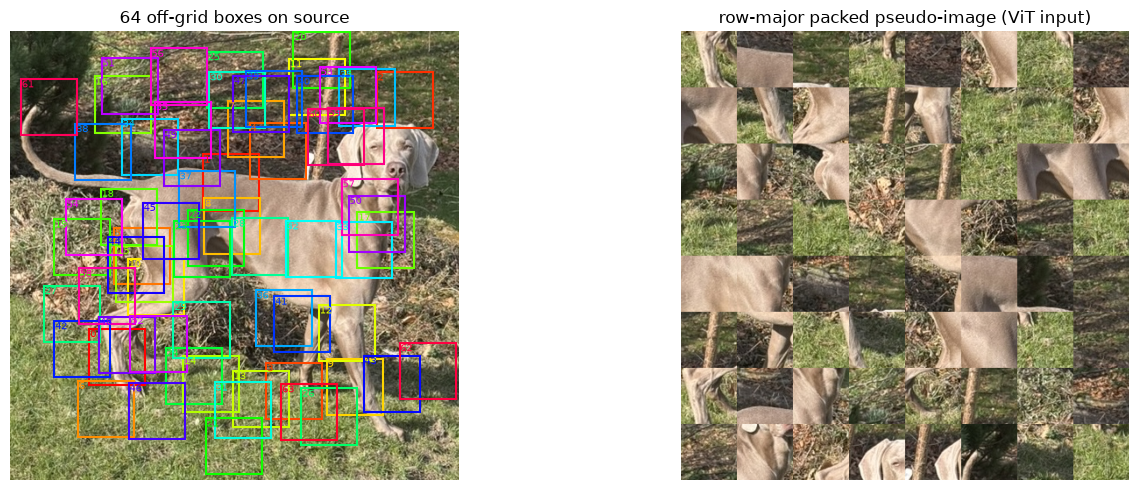

In [7]:
retiled = retile_patches(patches, IMG_SIZE)
print("retiled:", tuple(retiled.shape))

show_sampling_overview(image, boxes, patches, retiled)
plt.show()

## Recap

- **off-grid** boxes → continuous positions, overlapping, not grid-aligned;
- **constant size** → no scale signal (the translation-only baseline geometry);
- **packing** → the ViT sees a scrambled tile of patches with no positions.

Next steps will build the *relative target* between patch pairs (the differencing
that happens in `engine.py`), and eventually add the relative-orientation channel
`Δφ` that defines RoPART.

## 5. Relative translation target between patches

So far we have patches but no supervision. PART's pretext task never reveals
*where* a patch is; instead, for every **ordered pair** of patches `(i, j)` it
asks the network to predict the **relative transform** taking reference `i` to
target `j`. For the translation-only baseline that transform is just
`(Δx, Δy)`.

Upstream builds this inside the training step
(`PART/engine.py::pretrain_model`, `v3` branch) by differencing the absolute
patch coordinates over *all* ordered pairs into a `[2, N, N]` table. Our
`relative_translation` helper is that, reduced to the two translation channels:

$$\text{delta}[c, i, j] = \text{pos}_j - \text{pos}_i, \quad c \in \{x, y\}$$

with `i` = reference, `j` = target. **`pos` is the patch centre**, differenced in
the **global / image frame** — the project default. The centre is the
rotation-invariant anchor, so the translation channel stays decoupled from `Δφ`
once we add rotation. At `φ = 0` / constant patch size this is numerically
identical to the corner-difference upstream's non-centred path uses (reachable via
`centered=False`).

In [8]:
from helpers import relative_translation, patch_positions, check_translation_invariants, show_pair

positions = patch_positions(boxes)       # (2, N): patch centres (cx, cy)
delta_pix = relative_translation(boxes)                       # pixels
delta = relative_translation(boxes, normalize_by=PATCH_SIZE)  # patch-width units (training target)

print("positions  :", tuple(positions.shape))
print("delta table:", tuple(delta.shape), "= (channel, reference i, target j)")
print("\nexample — reference i=0 centre:", positions[:, 0].tolist())
print("          target    j=1 centre:", positions[:, 1].tolist())
print("  Δ(0→1) pixels      :", delta_pix[:, 0, 1].tolist())
print("  Δ(0→1) normalised  :", [round(v, 3) for v in delta[:, 0, 1].tolist()])

positions  : (2, 64)
delta table: (2, 64, 64) = (channel, reference i, target j)

example — reference i=0 centre: [122.0, 371.0]
          target    j=1 centre: [252.0, 172.0]
  Δ(0→1) pixels      : [130.0, -199.0]
  Δ(0→1) normalised  : [2.031, -3.109]


### Structural invariants

The target table is not arbitrary — it has two properties that act as a
correctness gate (and, for rotation later, become the *rotational* negative
symmetry we will measure):

- **zero diagonal**: a patch has zero relative translation to itself, `Δ(i→i)=0`;
- **negative symmetry**: `Δ(i→j) = −Δ(j→i)`.

In [9]:
check_translation_invariants(delta)
check_translation_invariants(delta_pix)
print("invariants hold: zero diagonal + negative symmetry ✔")

# show negative symmetry explicitly on one pair
print("\nΔ(0→1) =", delta_pix[:, 0, 1].tolist())
print("Δ(1→0) =", delta_pix[:, 1, 0].tolist(), " (= −Δ(0→1))")
print("Δ(5→5) =", delta_pix[:, 5, 5].tolist(), " (diagonal → 0)")

invariants hold: zero diagonal + negative symmetry ✔

Δ(0→1) = [130.0, -199.0]
Δ(1→0) = [-130.0, 199.0]  (= −Δ(0→1))
Δ(5→5) = [0.0, 0.0]  (diagonal → 0)


### A few pairs, as coordinates

Pick some ordered pairs and print their centres and translation, in pixels and in
the normalised (patch-width) units the network is actually trained on. Note the
sign flip between `(0,1)` and `(1,0)`, and the zero on the diagonal `(5,5)`.

In [10]:
pairs = [(0, 1), (1, 0), (5, 5), (10, 42), (42, 10)]

print(f"{'i':>3} {'j':>3} | {'centre_i':>14} {'centre_j':>14} | "
      f"{'Δ pixels':>16} | {'Δ patch-widths':>16}")
print("-" * 78)
for i, j in pairs:
    pi = positions[:, i].tolist()
    pj = positions[:, j].tolist()
    dpx = delta_pix[:, i, j].tolist()
    dn = delta[:, i, j].tolist()
    print(f"{i:>3} {j:>3} | ({pi[0]:>4.0f},{pi[1]:>4.0f})    "
          f"({pj[0]:>4.0f},{pj[1]:>4.0f})    "
          f"| ({dpx[0]:>+5.0f},{dpx[1]:>+5.0f})    "
          f"| ({dn[0]:>+5.2f},{dn[1]:>+5.2f})")

  i   j |       centre_i       centre_j |         Δ pixels |   Δ patch-widths
------------------------------------------------------------------------------
  0   1 | ( 122, 371)    ( 252, 172)    | ( +130, -199)    | (+2.03,-3.11)
  1   0 | ( 252, 172)    ( 122, 371)    | ( -130, +199)    | (-2.03,+3.11)
  5   5 | ( 150, 256)    ( 150, 256)    | (   +0,   +0)    | (+0.00,+0.00)
 10  42 | ( 166, 291)    (  82, 362)    | (  -84,  +71)    | (-1.31,+1.11)
 42  10 | (  82, 362)    ( 166, 291)    | (  +84,  -71)    | (+1.31,-1.11)


### See the pairs

`show_pair` draws the reference (blue) and target (red) patches on the source
image with the translation arrow `i → j` (between patch centres — the same vector
the target encodes), alongside the two cropped patches and their centre
coordinates.

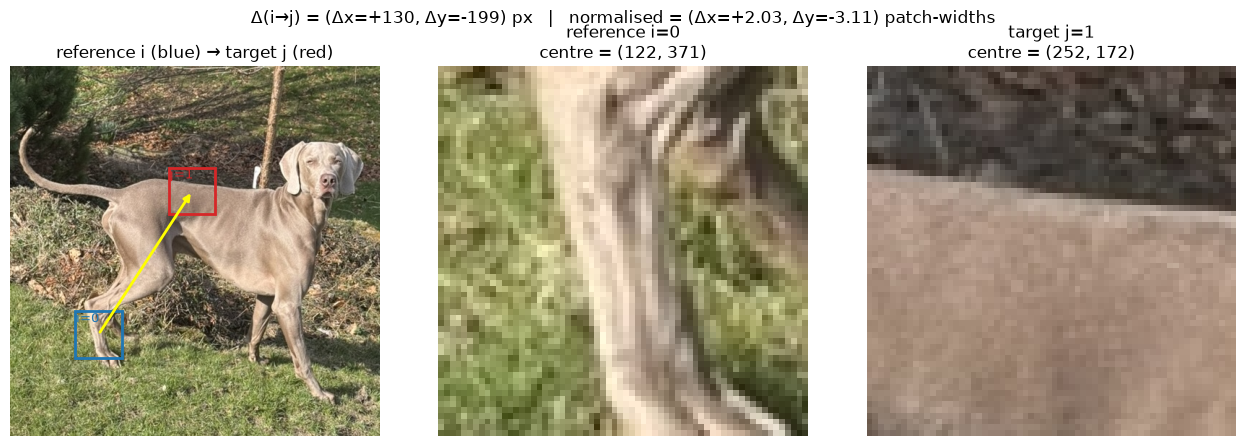

In [11]:
show_pair(image, boxes, 0, 1, patch_size=PATCH_SIZE)
plt.show()

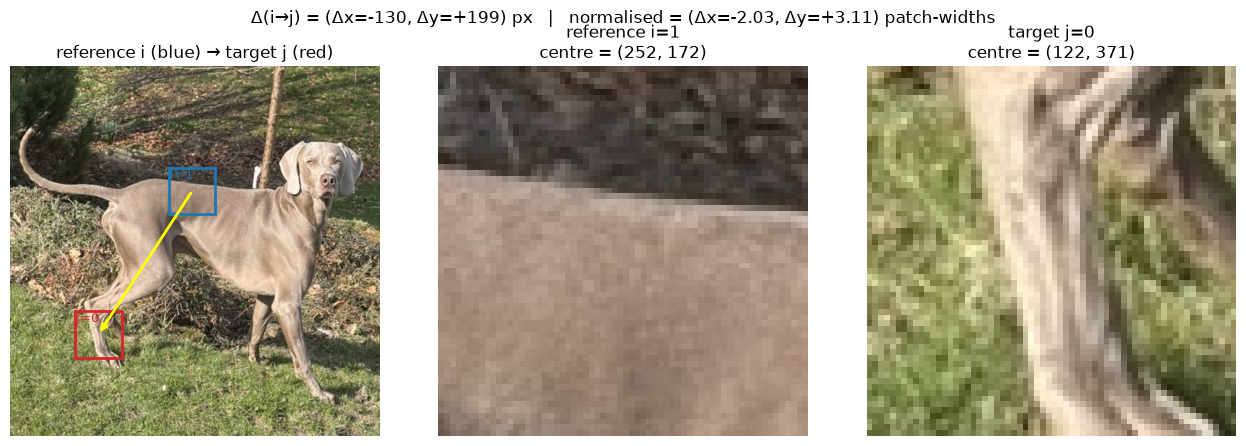

In [12]:
# the reverse pair — same patches, opposite arrow and sign (negative symmetry)
show_pair(image, boxes, 1, 0, patch_size=PATCH_SIZE)
plt.show()

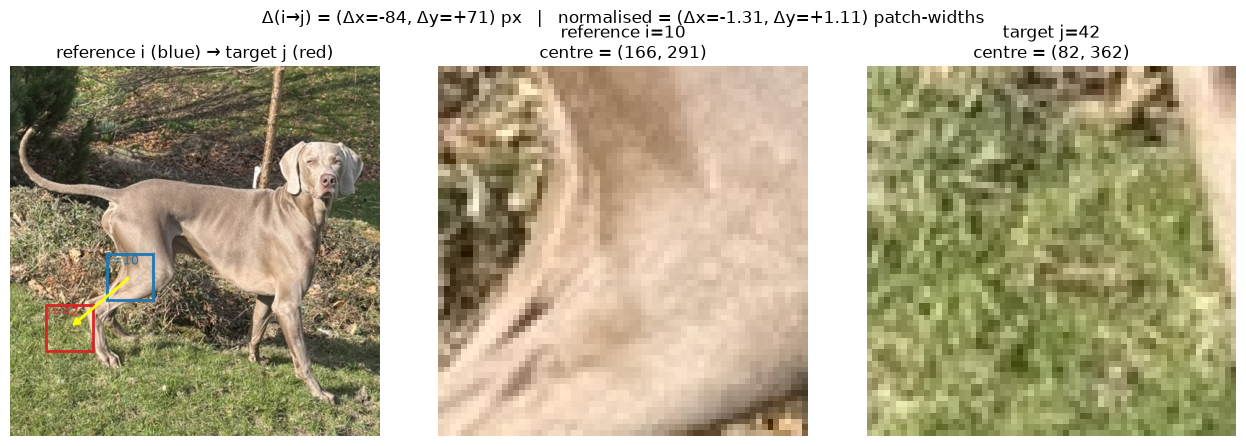

In [13]:
show_pair(image, boxes, 10, 42, patch_size=PATCH_SIZE)
plt.show()

### The whole target table

Finally, the full `N × N` translation table as two heatmaps (Δx and Δy). The
anti-symmetry is visible directly: each map equals the negative of its transpose,
and the diagonal is zero.

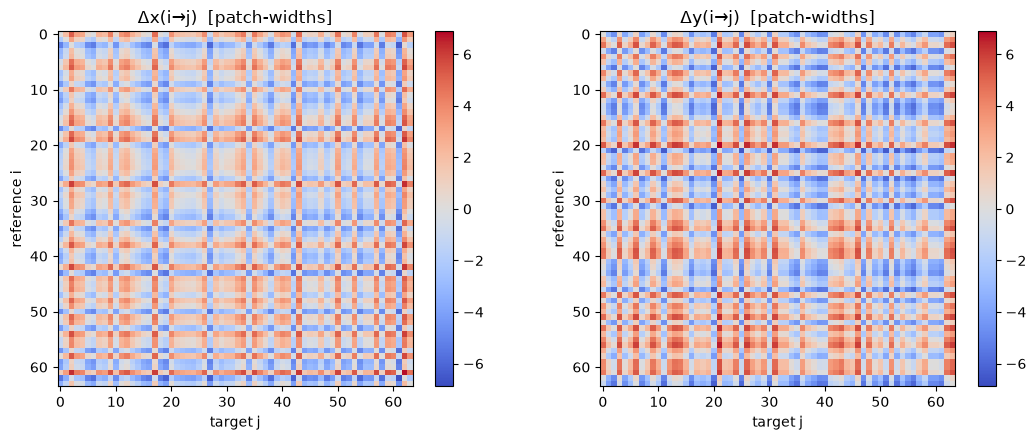

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
vmax = delta.abs().max()
for ax, c, name in zip(axes, range(2), ("Δx", "Δy")):
    im = ax.imshow(delta[c], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{name}(i→j)  [patch-widths]")
    ax.set_xlabel("target j")
    ax.set_ylabel("reference i")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()

## Recap

- the supervision is the **relative** transform between ordered patch pairs, not
  absolute position;
- for the baseline it is `(Δx, Δy)` = `centre_j − centre_i` (centred, global
  frame — the project default), normalised by patch width — a `[2, N, N]` table;
- it satisfies **zero diagonal** and **negative symmetry** `Δ(i→j) = −Δ(j→i)`.

Next: add the relative **orientation** channel `Δφ` as `(cos Δφ, sin Δφ)` — the
RoPART contribution — which will need patches that are actually rotated when
cropped, and a rotational analogue of these same invariants.